### Análisis del Caso 1: Latencia RAG

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from montecarlo_lib.simuladores import simular_latencia_rag

In [2]:
resultados_rag = simular_latencia_rag(
    mu_emb=50, sigma_emb=10,
    low_db=10, high_db=30,
    mean_llm=4.5, sigma_llm=0.5,
    num_simulaciones=100000,
    semilla=42
)
print(f"Latencia Promedio: {np.mean(resultados_rag['latencias']):.2f} ms")
print(f"Percentil 95: {resultados_rag['percentil_95']:.2f} ms")

Latencia Promedio: 171.90 ms
Percentil 95: 276.09 ms


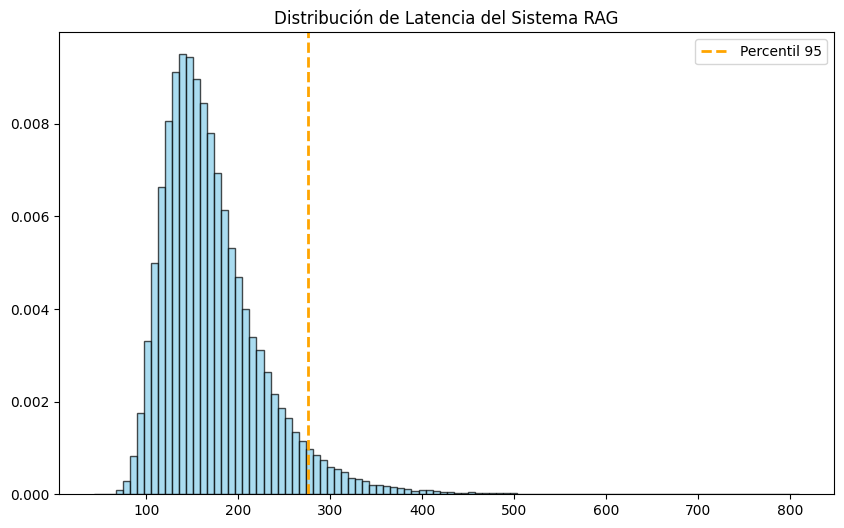

In [3]:
plt.figure(figsize=(10, 6))
plt.hist(resultados_rag['latencias'], bins=100, color='skyblue', edgecolor='black', alpha=0.7, density=True)
plt.axvline(resultados_rag['percentil_95'], color='orange', linestyle='dashed', linewidth=2, label='Percentil 95')
plt.title('Distribución de Latencia del Sistema RAG')
plt.legend()
plt.show()

Al emplear el método de Montecarlo con 100,000 simulaciones vectorizadas, la distribución resultante de la latencia presenta un claro sesgo a la derecha es decir una asimetría positiva. 

* **Impacto de las distribuciones subyacentes:** Mientras que la generación de embeddings  y la búsqueda en BD tienen comportamientos estables y acotados, la etapa de inferencia del LLM introduce una cola pesada. Esto significa que una minoría de consultas sufrirá latencias desproporcionadamente altas.
* **Evaluación del SLA:** El uso del promedio aritmético sería engañoso aquí. Gracias al cálculo estocástico, podemos basar nuestro Service Level Agreement en el Percentil 95, garantizando a los usuarios que el 95% de sus consultas se resolverán en un tiempo inferior a dicho umbral la línea naranja de la gráfica, permitiéndonos dimensionar la infraestructura correctamente para los casos límite.

## Análisis del Caso 2: Importance Sampling

In [1]:
from montecarlo_lib.simuladores import simular_importance_sampling

MEDIA = 12.0
DESVIACION = 2.0
LIMITE = 14.8

resultados_is = simular_importance_sampling(
    mu_f=MEDIA, 
    sigma_f=DESVIACION, 
    limite=LIMITE, 
    num_simulaciones=100000, 
    semilla=42
)

print(f"Probabilidad estimada (IS): {resultados_is['prob_is']:.6e}")
print(f"Varianza IS: {resultados_is['var_is']:.6e}")
print(f"Varianza MC Estándar (Teórica): {resultados_is['var_mc_teorica']:.6e}")
print(f"Factor de reducción de varianza: {resultados_is['reduccion_varianza']:.2f}x")

Probabilidad estimada (IS): 8.082429e-02
Varianza IS: 1.390177e-09
Varianza MC Estándar (Teórica): 7.429173e-07
Factor de reducción de varianza: 534.40x


**Estimación del Evento Raro**
En este escenario evaluamos la probabilidad de un fallo crítico que el pipeline bioinformático supere el límite de tiempo establecido. Al ser un evento extremo que se encuentra en la cola larga de la distribución normal, su probabilidad de ocurrencia es sumamente baja, pero su impacto en el sistema es catastrófico.

**La Limitación del Monte Carlo Estándar**
Si utilizáramos el método de Monte Carlo tradicional para modelar este problema, la inmensa mayoría de las iteraciones caerían en tiempos de ejecución normales. Tendríamos que ejecutar millones de simulaciones para obtener apenas un puñado de fallos, lo que se refleja en una Varianza Estándar muy alta para el nivel de precisión requerido. Es computacionalmente ineficiente.

**Eficiencia del Muestreo de Importancia (Importance Sampling)**
Al aplicar Importance Sampling, cambiamos las reglas del juego, usamos una distribución de propuesta para forzar al algoritmo a generar muestras exclusivamente en la zona de riesgo. Luego, corregimos este sesgo multiplicando por la razón de densidades en pesos. 

**Conclusión del Factor de Reducción**
El éxito de esta técnica se demuestra en el Factor de reducción de varianza. Este multiplicador nos indica que la varianza de nuestro estimador (Varianza IS) es significativamente menor que la teórica del método estándar. En términos de infraestructura, logramos estimar la probabilidad real del fallo con altísima precisión sin desperdiciar recursos computacionales esperando a que el evento raro ocurra por azar.

## Análisis del caso 3: Rejection Sampling

--- Caso 3: Rejection Sampling Bimodal ---
Constante empírica (k): 25.2
Tasa de Aceptación: 30.31%
Desperdicio de CPU (Muestras rechazadas): 69.69%



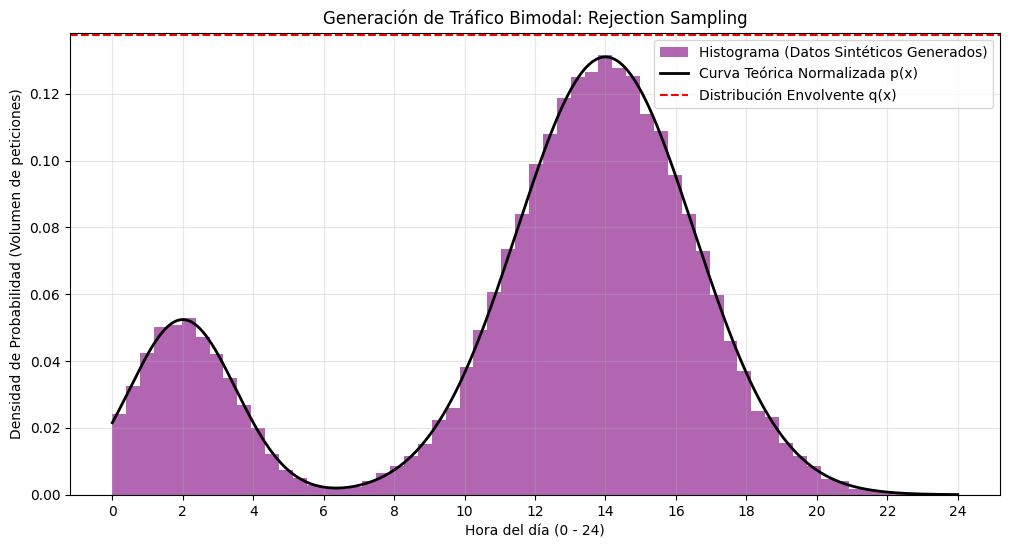

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from montecarlo_lib.simuladores import simular_rejection_sampling

# Se ejecuta la simulación
resultados_rs = simular_rejection_sampling(num_muestras=50000, semilla=42)
muestras = resultados_rs["muestras"]
p_star = resultados_rs["funcion_p_star"]
k = resultados_rs["k"]
tasa_aceptacion = resultados_rs["tasa_aceptacion"]

# Se muestran los indicadores de eficiencia
print("--- Caso 3: Rejection Sampling Bimodal ---")
print(f"Constante empírica (k): {k}")
print(f"Tasa de Aceptación: {tasa_aceptacion * 100:.2f}%")
print(f"Desperdicio de CPU (Muestras rechazadas): {(1 - tasa_aceptacion) * 100:.2f}%\n")

# Se grafica el resultado
plt.figure(figsize=(12, 6))

x_vals = np.linspace(0, 24, 1000)

plt.hist(muestras, bins=60, density=True, alpha=0.6, color='purple', label='Histograma (Datos Sintéticos Generados)')

area_bajo_curva = np.trapezoid(p_star(x_vals), x_vals) 
plt.plot(x_vals, p_star(x_vals) / area_bajo_curva, 'k-', linewidth=2, label='Curva Teórica Normalizada p(x)')

envolvente_normalizada = (k * (1/24)) / area_bajo_curva
plt.axhline(y=envolvente_normalizada, color='red', linestyle='--', label='Distribución Envolvente q(x)')

plt.title('Generación de Tráfico Bimodal: Rejection Sampling')
plt.xlabel('Hora del día (0 - 24)')
plt.ylabel('Densidad de Probabilidad (Volumen de peticiones)')
plt.xticks(np.arange(0, 25, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Precisión de la Simulación Bimodal**
Como se observa en la gráfica, el histograma de los datos sintéticos generados en morado muestra perfectamente la curva teórica bimodal marcada con línea negra. Esto confirma que el algoritmo de Rejection Sampling logró capturar con éxito los dos comportamientos del servidor, el pico menor de la madrugada y el pico principal del mediodía.

**Análisis de Eficiencia y la Distribución Envolvente**
La línea roja punteada representa nuestra distribución envolvente $q(x)$ . Toda el área visual que existe entre esa línea roja y la curva negra representa el desperdicio computacional. Al usar una distribución uniforme que debe ser lo suficientemente alta para cubrir el pico máximo de las 14:00, el algoritmo propone muchísimas muestras en los valles de tráfico como a las 8:00 o a las 20:00. Estas muestras invariablemente caen por encima de la curva negra y son rechazadas, lo que explica la alta tasa de muestras descartadas es decir el desperdicio de CPU.

**Optimización mediante Vectorización**
A pesar de que el método genera un volumen sustancial de muestras rechazadas, el tiempo de ejecución en la simulación fue casi instantáneo. Este rendimiento se logra gracias al empleo dominante de la vectorización con NumPy. Al evaluar los arreglos matriciales de forma simultánea en la memoria, evitamos el uso de bucles `for` iterativos, compensando la ineficiencia matemática del Rejection Sampling uniforme con fuerza bruta computacional altamente optimizada.